# 4.3 Subsection

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import label
from math import radians, sin, cos, asin, sqrt
import heapq
from datetime import datetime

plt.rcParams["figure.dpi"] = 120

# -----------------------------
# Paths (adjust to your structure)
# -----------------------------
BATHY_FILE = (
    "arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc"
)
ICE_FILE = (
    "arctic_routing_paperA/data/raw/seaice_cmems/cmems_arc_seaice_2018_JJAS_subset.nc"
    # adjust to your actual filename
)

# -----------------------------
# 1. Load GEBCO & build 0.5° routing grid
# -----------------------------
ds_bathy = xr.open_dataset(BATHY_FILE)

lat_full = ds_bathy["lat"].values
lon_full = ds_bathy["lon"].values
elev_full = ds_bathy["elevation"].values  # GEBCO elevation: negative = sea

lat_rg = np.arange(40.5, 84.5 + 1e-6, 0.5)
lon_rg = np.arange(-19.5, 179.5 + 1e-6, 0.5)
lon_rg_2d, lat_rg_2d = np.meshgrid(lon_rg, lat_rg)

# nearest-neighbour regrid (same logic as before)
lat_idx = np.abs(lat_full[:, None] - lat_rg[None, :]).argmin(axis=0)
lon_idx = np.abs(lon_full[:, None] - lon_rg[None, :]).argmin(axis=0)
depth_rg = elev_full[lat_idx[:, None], lon_idx[None, :]].astype(float)

sea_mask_rg = depth_rg <= 0.0  # True = sea

print("Routing depth stats:")
print("  shape:", depth_rg.shape)
print("  min:", depth_rg.min(), "max:", depth_rg.max())
print("Sea fraction:", sea_mask_rg.mean())

# -----------------------------
# 2. Canonical OD and A*
# -----------------------------
start_idx = (0, 0)        # (lat=40.5, lon=-19.5)
goal_idx  = (58, 398)     # (lat=69.5, lon=179.5)

start_lat, start_lon = lat_rg[start_idx[0]], lon_rg[start_idx[1]]
goal_lat,  goal_lon  = lat_rg[goal_idx[0]],  lon_rg[goal_idx[1]]

print("Start index:", start_idx, "->", start_lat, start_lon)
print("Goal index :", goal_idx,  "->", goal_lat, goal_lon)

def haversine_nm(lat1, lon1, lat2, lon2):
    R_km = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2.0)**2 + cos(lat1)*cos(lat2)*sin(dlon/2.0)**2
    c = 2.0*asin(sqrt(a))
    dist_km = R_km * c
    return dist_km / 1.852  # km -> NM

NEIGH_OFFSETS = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

def astar_route(mask, start, goal, lat_grid, lon_grid):
    n_i, n_j = mask.shape
    si, sj = start
    gi, gj = goal

    def in_bounds(i, j):
        return 0 <= i < n_i and 0 <= j < n_j

    def heuristic(i, j):
        return haversine_nm(lat_grid[i, j], lon_grid[i, j],
                            lat_grid[gi, gj], lon_grid[gi, gj])

    open_heap = []
    heapq.heappush(open_heap, (0.0, (si, sj)))
    g_score = {(si, sj): 0.0}
    came_from = {}
    visited = 0

    while open_heap:
        _, (i, j) = heapq.heappop(open_heap)
        visited += 1
        if (i, j) == (gi, gj):
            path = [(i, j)]
            while (i, j) in came_from:
                (i, j) = came_from[(i, j)]
                path.append((i, j))
            path.reverse()
            print(f"  A*: reached goal after visiting {visited} nodes.")
            return path

        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if not in_bounds(ni, nj):
                continue
            if not mask[ni, nj]:
                continue

            cost_ij = haversine_nm(lat_grid[i, j], lon_grid[i, j],
                                   lat_grid[ni, nj], lon_grid[ni, nj])
            tentative = g_score[(i, j)] + cost_ij

            if (ni, nj) not in g_score or tentative < g_score[(ni, nj)]:
                g_score[(ni, nj)] = tentative
                f = tentative + heuristic(ni, nj)
                heapq.heappush(open_heap, (f, (ni, nj)))
                came_from[(ni, nj)] = (i, j)

    raise RuntimeError("A*: No path found.")

# Baseline GC distance (for ratios later)
GC_NM = haversine_nm(start_lat, start_lon, goal_lat, goal_lon)
print(f"Great-circle distance: {GC_NM:.1f} NM")

Routing depth stats:
  shape: (89, 399)
  min: -8709.0 max: 5526.0
Sea fraction: 0.48373743347131876
Start index: (0, 0) -> 40.5 -19.5
Goal index : (58, 398) -> 69.5 179.5
Great-circle distance: 4149.6 NM


In [5]:
# -----------------------------
# 3. Load CMEMS sea-ice dataset
# -----------------------------
ds_ice = xr.open_dataset(ICE_FILE)

print(ds_ice)

lat_ice = ds_ice["latitude"].values
lon_ice = ds_ice["longitude"].values
time_ice = ds_ice["time"].values
siconc = ds_ice["siconc"]  # [time, latitude, longitude], 0-1

print("Ice lat range:", lat_ice.min(), lat_ice.max())
print("Ice lon range:", lon_ice.min(), lon_ice.max())
print("Time range:", str(time_ice[0]), "to", str(time_ice[-1]))

<xarray.Dataset> Size: 15GB
Dimensions:    (time: 122, latitude: 1000, longitude: 7667)
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Data variables:
    siconc     (time, latitude, longitude) float64 7GB ...
    sithick    (time, latitude, longitude) float64 7GB ...
Attributes:
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    references:                https://marine.copernicus.eu/
    credit:                    E.U. Copernicus Marine Service Information (CM...
    Conventions:               CF-1.6
    copernicusmarine_version:  2.2.5
Ice lat range: 60.00000000000038 89.9700000000015
Ice

In [10]:
def ice_metrics_for_date(target_date_str, thr_ice=0.15):
    """
    target_date_str: 'YYYY-MM-DD'
    thr_ice: SIC threshold in [0,1] (e.g. 0.15 for 15%)
    Returns dict with:
      - date (datetime64)
      - ice_safe_pct_of_sea
      - n_components
      - route_exists
      - route_nm
      - ratio
    """
    target_dt = np.datetime64(target_date_str)

    # --- Robust nearest-time selection ---
    time_vals = ds_ice["time"].values
    idx_nearest = int(np.argmin(np.abs(time_vals - target_dt)))
    t_sel = time_vals[idx_nearest]

    # Extract siconc at that time
    siconc_t = ds_ice["siconc"].isel(time=idx_nearest)  # 2D [lat, lon]

    # --- Regrid to routing grid (bilinear) ---
    siconc_rg = siconc_t.interp(
        latitude=("latitude", lat_rg),
        longitude=("longitude", lon_rg),
        method="linear"
    ).values  # shape (n_lat, n_lon)

    # Treat out-of-domain NaNs as ice-free (SIC = 0)
    nan_frac = np.isnan(siconc_rg).mean()
    print(f"{target_date_str}: NaN fraction in regridded SIC = {nan_frac:.3f}")
    siconc_rg = np.where(np.isnan(siconc_rg), 0.0, siconc_rg)

    # --- Ice-safe sea mask: sea & SIC < thr ---
    ice_safe_mask = np.logical_and(sea_mask_rg, siconc_rg < thr_ice)

    sea_fraction = sea_mask_rg.mean()
    ice_safe_fraction = ice_safe_mask.mean()
    ice_safe_pct_of_sea = 100.0 * ice_safe_fraction / sea_fraction

    labels, ncomp = label(
        ice_safe_mask.astype(int),
        structure=np.ones((3, 3), int)
    )

    start_label = labels[start_idx]
    goal_label  = labels[goal_idx]
    route_exists = (start_label > 0) and (start_label == goal_label)

    route_nm = np.nan
    ratio = np.nan

    if route_exists:
        path_idx = astar_route(
            ice_safe_mask,
            start_idx,
            goal_idx,
            lat_rg_2d,
            lon_rg_2d,
        )
        route_lat = np.array([lat_rg[i] for i, j in path_idx])
        route_lon = np.array([lon_rg[j] for i, j in path_idx])

        dist_cum_nm = 0.0
        for k in range(1, len(route_lat)):
            dist_cum_nm += haversine_nm(
                route_lat[k-1], route_lon[k-1],
                route_lat[k],   route_lon[k],
            )
        route_nm = dist_cum_nm
        ratio = route_nm / GC_NM

    print(
        f"{target_date_str} (nearest {np.datetime_as_string(t_sel, unit='D')}): "
        f"ice-safe sea={ice_safe_pct_of_sea:5.1f}% of sea, "
        f"components={ncomp}, route={route_exists}, "
        f"route_nm={route_nm if route_exists else np.nan:.1f}, "
        f"ratio={ratio if route_exists else np.nan:.3f}"
    )

    return dict(
        date=np.datetime64(target_date_str),
        ice_safe_pct_of_sea=ice_safe_pct_of_sea,
        n_components=int(ncomp),
        route_exists=bool(route_exists),
        route_nm=float(route_nm) if route_exists else np.nan,
        ratio=float(ratio) if route_exists else np.nan,
    )

In [11]:
seasonal_dates = ["2018-06-15", "2018-07-15", "2018-08-15", "2018-09-15"]

results = [ice_metrics_for_date(d, thr_ice=0.15) for d in seasonal_dates]
df_seasonal = pd.DataFrame(results).sort_values("date").reset_index(drop=True)
print("\nSeasonal DataFrame:")
print(df_seasonal)

2018-06-15: NaN fraction in regridded SIC = 0.712
2018-06-15 (nearest 2018-06-15): ice-safe sea= 58.9% of sea, components=113, route=False, route_nm=nan, ratio=nan
2018-07-15: NaN fraction in regridded SIC = 0.712
2018-07-15 (nearest 2018-07-15): ice-safe sea= 65.8% of sea, components=70, route=False, route_nm=nan, ratio=nan
2018-08-15: NaN fraction in regridded SIC = 0.712
  A*: reached goal after visiting 17590 nodes.
2018-08-15 (nearest 2018-08-15): ice-safe sea= 77.1% of sea, components=31, route=True, route_nm=5203.0, ratio=1.254
2018-09-15: NaN fraction in regridded SIC = 0.712
  A*: reached goal after visiting 17991 nodes.
2018-09-15 (nearest 2018-09-15): ice-safe sea= 80.8% of sea, components=30, route=True, route_nm=5020.4, ratio=1.210

Seasonal DataFrame:
        date  ice_safe_pct_of_sea  n_components  route_exists     route_nm  \
0 2018-06-15            58.865991           113         False          NaN   
1 2018-07-15            65.758528            70         False       

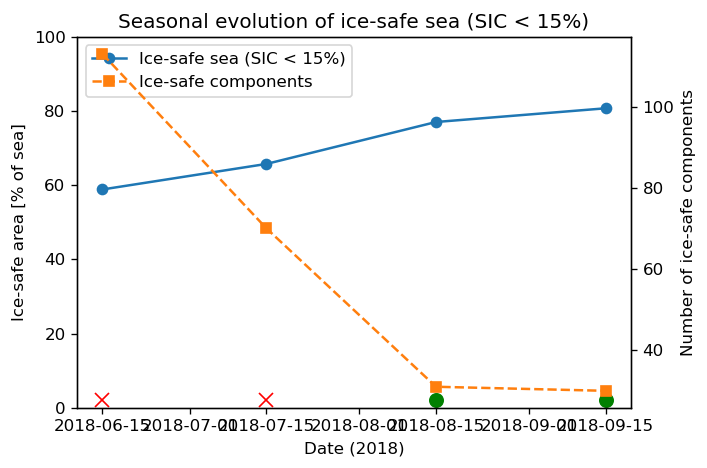

In [12]:
# -----------------------------
# 6. FIGURE: seasonal ice-safe sea fraction & components
# -----------------------------

fig, ax1 = plt.subplots(figsize=(6, 4))

# Convert dates to matplotlib-friendly
dates = pd.to_datetime(df_seasonal["date"])

# Left axis: ice-safe sea fraction (% of sea)
ax1.plot(dates,
         df_seasonal["ice_safe_pct_of_sea"],
         "o-", label="Ice-safe sea (SIC < 15%)")
ax1.set_xlabel("Date (2018)")
ax1.set_ylabel("Ice-safe area [% of sea]")
ax1.set_ylim(0, 100)

# connectivity markers (route exists or not)
for d, ok in zip(dates, df_seasonal["route_exists"]):
    y = ax1.get_ylim()[0] + 2.0
    ax1.plot(d, y, "go" if ok else "rx", ms=8)

# Right axis: number of components
ax2 = ax1.twinx()
ax2.plot(dates,
         df_seasonal["n_components"],
         "s--", color="tab:orange",
         label="Ice-safe components")
ax2.set_ylabel("Number of ice-safe components")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Seasonal evolution of ice-safe sea (SIC < 15%)")

plt.tight_layout()
plt.savefig("fig05_seasonal_ice_area.png", dpi=300)
plt.show()

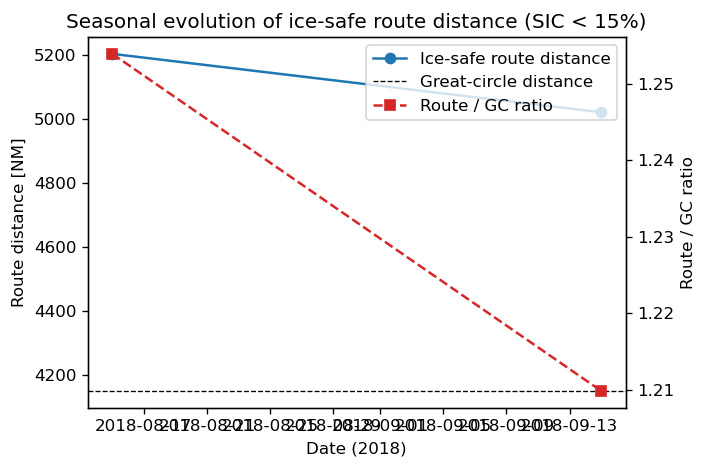

In [13]:
# -----------------------------
# 7. FIGURE: seasonal route distance & ratio
# -----------------------------

fig, ax1 = plt.subplots(figsize=(6, 4))

# Mask out dates without routes
mask_route = df_seasonal["route_exists"].values
dates_route = dates[mask_route]
route_nm = df_seasonal.loc[mask_route, "route_nm"].values
ratio = df_seasonal.loc[mask_route, "ratio"].values

# Left axis: route distance (NM)
ax1.plot(dates_route, route_nm, "o-", label="Ice-safe route distance")
ax1.axhline(GC_NM, color="k", linestyle="--", linewidth=0.8,
            label="Great-circle distance")
ax1.set_xlabel("Date (2018)")
ax1.set_ylabel("Route distance [NM]")

# Right axis: route/GC ratio
ax2 = ax1.twinx()
ax2.plot(dates_route, ratio, "s--", color="tab:red",
         label="Route / GC ratio")
ax2.set_ylabel("Route / GC ratio")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Seasonal evolution of ice-safe route distance (SIC < 15%)")

plt.tight_layout()
plt.savefig("fig06_seasonal_route_distance.png", dpi=300)
plt.show()

# Should be in seperate subsection 4.4

---

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import label

def ice_route_for_date_and_threshold(target_date_str, thr_ice):
    """
    Compute ice-safe fraction, components, and route metrics
    for a given date and SIC threshold.

    Returns dict with:
      - date
      - thr_pct
      - ice_safe_pct_of_sea
      - n_components
      - route_exists
      - route_nm
      - ratio
    """
    target_dt = np.datetime64(target_date_str)
    time_vals = ds_ice["time"].values

    # nearest time index
    idx_nearest = int(np.argmin(np.abs(time_vals - target_dt)))
    t_sel = time_vals[idx_nearest]

    # 2D SIC slice at that time
    siconc_t = ds_ice["siconc"].isel(time=idx_nearest)  # [lat, lon]

    # Regrid to routing grid
    siconc_rg = siconc_t.interp(
        latitude=("latitude", lat_rg),
        longitude=("longitude", lon_rg),
        method="linear"
    ).values  # (n_lat, n_lon)

    # Treat NaNs as ice-free
    nan_frac = np.isnan(siconc_rg).mean()
    print(f"{target_date_str}, thr={thr_ice:.2f}: NaN fraction={nan_frac:.3f}")
    siconc_rg = np.where(np.isnan(siconc_rg), 0.0, siconc_rg)

    # Ice-safe mask = sea & SIC < threshold
    ice_safe_mask = np.logical_and(sea_mask_rg, siconc_rg < thr_ice)

    sea_fraction = sea_mask_rg.mean()
    ice_safe_fraction = ice_safe_mask.mean()
    ice_safe_pct_of_sea = 100.0 * ice_safe_fraction / sea_fraction

    labels, ncomp = label(
        ice_safe_mask.astype(int),
        structure=np.ones((3, 3), int)
    )

    start_label = labels[start_idx]
    goal_label  = labels[goal_idx]
    route_exists = (start_label > 0) and (start_label == goal_label)

    route_nm = np.nan
    ratio = np.nan

    if route_exists:
        path_idx = astar_route(
            ice_safe_mask,
            start_idx,
            goal_idx,
            lat_rg_2d,
            lon_rg_2d,
        )
        route_lat = np.array([lat_rg[i] for i, j in path_idx])
        route_lon = np.array([lon_rg[j] for i, j in path_idx])

        dist_cum_nm = 0.0
        for k in range(1, len(route_lat)):
            dist_cum_nm += haversine_nm(
                route_lat[k-1], route_lon[k-1],
                route_lat[k],   route_lon[k],
            )
        route_nm = dist_cum_nm
        ratio = route_nm / GC_NM

    print(
        f"  ice-safe={ice_safe_pct_of_sea:5.1f}% of sea, "
        f"components={ncomp}, route={route_exists}, "
        f"route_nm={route_nm if route_exists else np.nan:.1f}, "
        f"ratio={ratio if route_exists else np.nan:.3f}"
    )

    return dict(
        date=np.datetime64(target_date_str),
        thr_pct=100.0 * thr_ice,
        ice_safe_pct_of_sea=ice_safe_pct_of_sea,
        n_components=int(ncomp),
        route_exists=bool(route_exists),
        route_nm=float(route_nm) if route_exists else np.nan,
        ratio=float(ratio) if route_exists else np.nan,
    )

In [15]:
# Thresholds in SIC fraction (0–1)
thr_list = [0.05, 0.10, 0.15, 0.30, 0.50]
fixed_date = "2018-09-15"

records = []
for thr in thr_list:
    rec = ice_route_for_date_and_threshold(fixed_date, thr)
    records.append(rec)

df_thr = pd.DataFrame(records)
df_thr

2018-09-15, thr=0.05: NaN fraction=0.712
  A*: reached goal after visiting 17982 nodes.
  ice-safe= 80.5% of sea, components=35, route=True, route_nm=5025.0, ratio=1.211
2018-09-15, thr=0.10: NaN fraction=0.712
  A*: reached goal after visiting 17974 nodes.
  ice-safe= 80.7% of sea, components=31, route=True, route_nm=5020.4, ratio=1.210
2018-09-15, thr=0.15: NaN fraction=0.712
  A*: reached goal after visiting 17991 nodes.
  ice-safe= 80.8% of sea, components=30, route=True, route_nm=5020.4, ratio=1.210
2018-09-15, thr=0.30: NaN fraction=0.712
  A*: reached goal after visiting 18062 nodes.
  ice-safe= 81.1% of sea, components=30, route=True, route_nm=5019.9, ratio=1.210
2018-09-15, thr=0.50: NaN fraction=0.712
  A*: reached goal after visiting 18187 nodes.
  ice-safe= 81.5% of sea, components=40, route=True, route_nm=5018.6, ratio=1.209


,date,thr_pct,ice_safe_pct_of_sea,n_components,route_exists,route_nm,ratio
0,2018-09-15,5.0,80.521597,35,True,5024.984911,1.210966
1,2018-09-15,10.0,80.696239,31,True,5020.392833,1.209859
2,2018-09-15,15.0,80.766096,30,True,5020.392833,1.209859
3,2018-09-15,30.0,81.121202,30,True,5019.874306,1.209735
4,2018-09-15,50.0,81.546164,40,True,5018.589856,1.209425


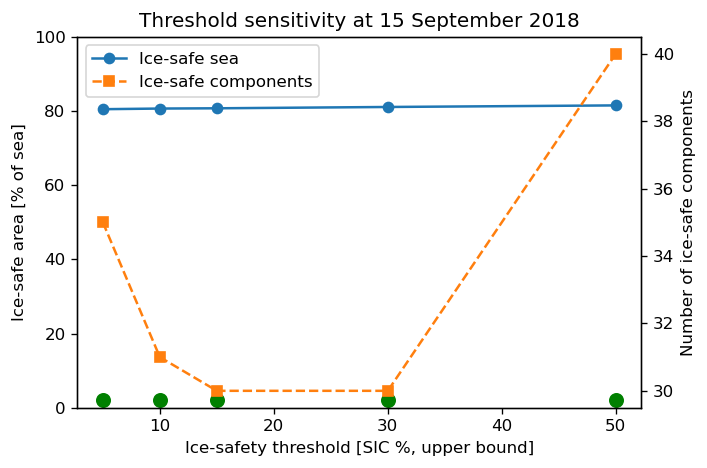

In [16]:
# FIGURE: threshold curves at 2018-09-15
fig, ax1 = plt.subplots(figsize=(6, 4))

# X-axis: threshold [%]
x = df_thr["thr_pct"].values

# Left axis: ice-safe area (% of sea)
ax1.plot(x,
         df_thr["ice_safe_pct_of_sea"].values,
         "o-", label="Ice-safe sea")
ax1.set_xlabel("Ice-safety threshold [SIC %, upper bound]")
ax1.set_ylabel("Ice-safe area [% of sea]")
ax1.set_ylim(0, 100)

# Mark route existence along bottom
for xi, ok in zip(x, df_thr["route_exists"].values):
    y = ax1.get_ylim()[0] + 2.0
    ax1.plot(xi, y, "go" if ok else "rx", ms=8)

# Right axis: number of components
ax2 = ax1.twinx()
ax2.plot(x,
         df_thr["n_components"].values,
         "s--", color="tab:orange",
         label="Ice-safe components")
ax2.set_ylabel("Number of ice-safe components")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Threshold sensitivity at 15 September 2018")

plt.tight_layout()
plt.savefig("fig07_ice_threshold_curves.png", dpi=300)
plt.show()

In [17]:
# Dates for heatmap
heatmap_dates = [
    "2018-06-15",
    "2018-07-01",
    "2018-07-15",
    "2018-08-01",
    "2018-08-15",
    "2018-09-01",
    "2018-09-15",
    "2018-09-30",
]

thr_list = [0.05, 0.10, 0.15, 0.30, 0.50]  # same thresholds as above

n_dates = len(heatmap_dates)
n_thr = len(thr_list)

ratio_mat = np.full((n_dates, n_thr), np.nan, dtype=float)
route_exists_mat = np.zeros((n_dates, n_thr), dtype=bool)

for i, d in enumerate(heatmap_dates):
    for j, thr in enumerate(thr_list):
        rec = ice_route_for_date_and_threshold(d, thr)
        ratio_mat[i, j] = rec["ratio"]
        route_exists_mat[i, j] = rec["route_exists"]

print("Ratio matrix (date x threshold):")
print(ratio_mat)

2018-06-15, thr=0.05: NaN fraction=0.712
  ice-safe= 58.4% of sea, components=113, route=False, route_nm=nan, ratio=nan
2018-06-15, thr=0.10: NaN fraction=0.712
  ice-safe= 58.6% of sea, components=112, route=False, route_nm=nan, ratio=nan
2018-06-15, thr=0.15: NaN fraction=0.712
  ice-safe= 58.9% of sea, components=113, route=False, route_nm=nan, ratio=nan
2018-06-15, thr=0.30: NaN fraction=0.712
  ice-safe= 59.8% of sea, components=115, route=False, route_nm=nan, ratio=nan
2018-06-15, thr=0.50: NaN fraction=0.712
  ice-safe= 61.1% of sea, components=124, route=False, route_nm=nan, ratio=nan
2018-07-01, thr=0.05: NaN fraction=0.712
  ice-safe= 60.8% of sea, components=109, route=False, route_nm=nan, ratio=nan
2018-07-01, thr=0.10: NaN fraction=0.712
  ice-safe= 61.1% of sea, components=109, route=False, route_nm=nan, ratio=nan
2018-07-01, thr=0.15: NaN fraction=0.712
  ice-safe= 61.5% of sea, components=104, route=False, route_nm=nan, ratio=nan
2018-07-01, thr=0.30: NaN fraction=0.712

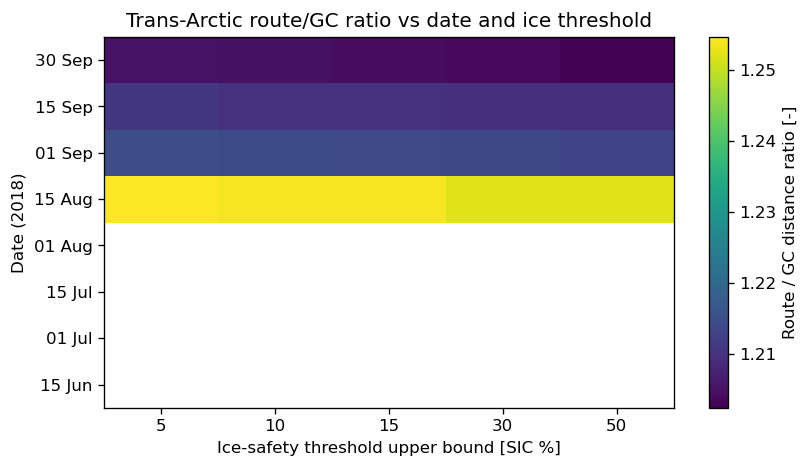

In [18]:
# FIGURE: date × threshold heatmap of route/GC ratio
fig, ax = plt.subplots(figsize=(7, 4))

# Use imshow; rows=dates, cols=thresholds
im = ax.imshow(
    ratio_mat,
    origin="lower",
    aspect="auto",
    interpolation="none",
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Route / GC distance ratio [-]")

# X tick labels = thresholds in %
ax.set_xticks(np.arange(n_thr))
ax.set_xticklabels([f"{int(100*t)}" for t in thr_list])

# Y tick labels = dates
ax.set_yticks(np.arange(n_dates))
ax.set_yticklabels(
    [pd.to_datetime(d).strftime("%d %b") for d in heatmap_dates]
)

ax.set_xlabel("Ice-safety threshold upper bound [SIC %]")
ax.set_ylabel("Date (2018)")
ax.set_title("Trans-Arctic route/GC ratio vs date and ice threshold")

# Mark cells where no route exists (e.g. with '×')
for i in range(n_dates):
    for j in range(n_thr):
        if not route_exists_mat[i, j]:
            ax.text(
                j, i, "×",
                ha="center", va="center",
                color="white", fontsize=10, fontweight="bold"
            )

plt.tight_layout()
plt.savefig("fig08_heatmap_date_threshold_ratio.png", dpi=300)
plt.show()

---

# Should be in subsection 4.5

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from matplotlib.colors import ListedColormap, BoundaryNorm

def joint_depth_ice_for_date(target_date_str, hmin=20.0, thr_ice=0.15):
    """
    Compute depth-safe, ice-safe and joint-safe masks for a given date
    and thresholds, plus connectivity info for canonical OD.

    Returns:
      dict with fractions (% of sea), component counts, connectivity flags,
      and the masks themselves.
    """
    target_dt = np.datetime64(target_date_str)
    time_vals = ds_ice["time"].values

    # --- Nearest time index ---
    idx_nearest = int(np.argmin(np.abs(time_vals - target_dt)))
    t_sel = time_vals[idx_nearest]

    siconc_t = ds_ice["siconc"].isel(time=idx_nearest)  # [lat, lon]

    # --- Regrid SIC to routing grid ---
    siconc_rg = siconc_t.interp(
        latitude=("latitude", lat_rg),
        longitude=("longitude", lon_rg),
        method="linear"
    ).values  # (n_lat, n_lon)

    nan_frac = np.isnan(siconc_rg).mean()
    print(f"{target_date_str}: NaN fraction in regridded SIC = {nan_frac:.3f}")
    # Treat NaN as ice-free
    siconc_rg = np.where(np.isnan(siconc_rg), 0.0, siconc_rg)

    # --- Masks ---
    sea_fraction = sea_mask_rg.mean()

    depth_safe_mask = np.logical_and(sea_mask_rg, depth_rg <= -hmin)
    ice_safe_mask   = np.logical_and(sea_mask_rg, siconc_rg < thr_ice)
    joint_mask      = np.logical_and(depth_safe_mask, ice_safe_mask)

    depth_safe_frac = 100.0 * depth_safe_mask.mean() / sea_fraction
    ice_safe_frac   = 100.0 * ice_safe_mask.mean()   / sea_fraction
    joint_frac      = 100.0 * joint_mask.mean()      / sea_fraction

    print(f"  Depth-safe (>= {hmin:.0f} m): {depth_safe_frac:5.1f}% of sea")
    print(f"  Ice-safe   (SIC < {thr_ice*100:.0f}%): {ice_safe_frac:5.1f}% of sea")
    print(f"  Joint-safe (depth+ice): {joint_frac:5.1f}% of sea")

    # --- Connectivity on joint-safe mask ---
    labels_joint, ncomp_joint = label(
        joint_mask.astype(int),
        structure=np.ones((3, 3), int)
    )
    start_label = labels_joint[start_idx]
    goal_label  = labels_joint[goal_idx]
    same_comp = (start_label > 0) and (start_label == goal_label)

    print(f"  Joint-safe components: {ncomp_joint}")
    print(f"  Labels (start, goal): {start_label} {goal_label}")
    print(f"  Start and goal in same joint-safe component? {same_comp}")

    route_nm = np.nan
    ratio = np.nan
    path_idx = None

    if same_comp:
        print("  Running A* on joint depth+ice mask ...")
        path_idx = astar_route(
            joint_mask,
            start_idx,
            goal_idx,
            lat_rg_2d,
            lon_rg_2d,
        )
        route_lat = np.array([lat_rg[i] for i, j in path_idx])
        route_lon = np.array([lon_rg[j] for i, j in path_idx])

        dist_cum_nm = 0.0
        for k in range(1, len(route_lat)):
            dist_cum_nm += haversine_nm(
                route_lat[k-1], route_lon[k-1],
                route_lat[k],   route_lon[k],
            )
        route_nm = dist_cum_nm
        ratio = route_nm / GC_NM

        print(f"  Joint-safe route distance: {route_nm:.1f} NM, "
              f"ratio={ratio:.3f}")
    else:
        print("  -> No continuous joint depth+ice route for this date/thresholds.")

    return dict(
        date=np.datetime64(target_date_str),
        hmin=hmin,
        thr_ice=thr_ice,
        depth_safe_frac=depth_safe_frac,
        ice_safe_frac=ice_safe_frac,
        joint_frac=joint_frac,
        n_components_joint=int(ncomp_joint),
        start_label=int(start_label),
        goal_label=int(goal_label),
        same_component=bool(same_comp),
        route_nm=float(route_nm) if same_comp else np.nan,
        ratio=float(ratio) if same_comp else np.nan,
        depth_safe_mask=depth_safe_mask,
        ice_safe_mask=ice_safe_mask,
        joint_mask=joint_mask,
        siconc_rg=siconc_rg,
        path_idx=path_idx,
    )

In [20]:
joint_res = joint_depth_ice_for_date(
    "2018-09-15",
    hmin=20.0,
    thr_ice=0.15,
)
joint_res

2018-09-15: NaN fraction in regridded SIC = 0.712
  Depth-safe (>= 20 m):  93.8% of sea
  Ice-safe   (SIC < 15%):  80.8% of sea
  Joint-safe (depth+ice):  74.6% of sea
  Joint-safe components: 35
  Labels (start, goal): 1 20
  Start and goal in same joint-safe component? False
  -> No continuous joint depth+ice route for this date/thresholds.


{'date': numpy.datetime64('2018-09-15'),
 'hmin': 20.0,
 'thr_ice': 0.15,
 'depth_safe_frac': 93.80020957038072,
 'ice_safe_frac': 80.76609616951916,
 'joint_frac': 74.64780533240192,
 'n_components_joint': 35,
 'start_label': 1,
 'goal_label': 20,
 'same_component': False,
 'route_nm': nan,
 'ratio': nan,
 'depth_safe_mask': array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]),
 'ice_safe_mask': array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
 

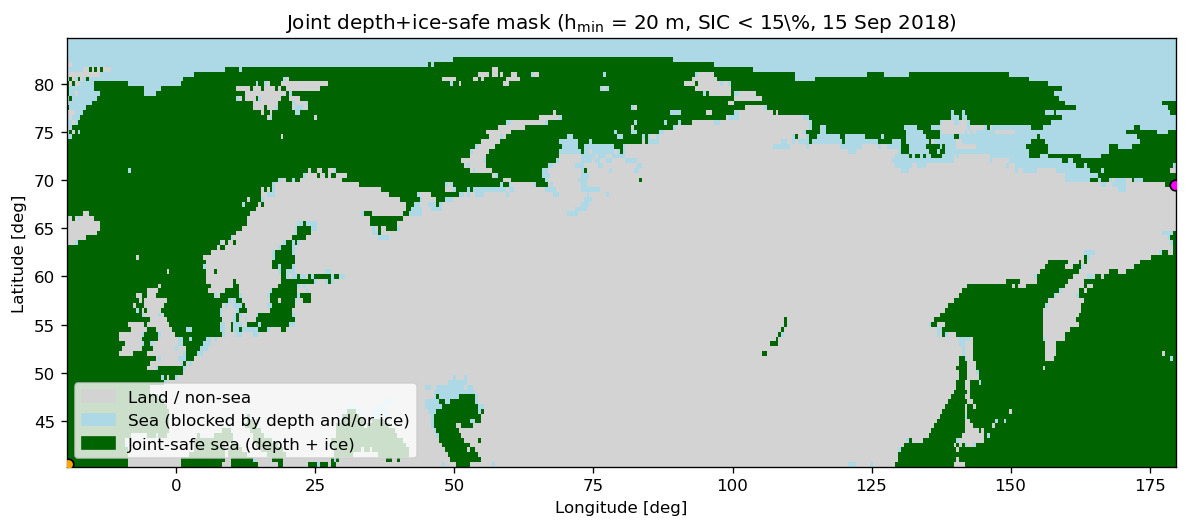

In [21]:
# Build a small integer classification grid:
# 0 = land/non-sea, 1 = sea but not joint-safe, 2 = joint-safe
class_grid = np.zeros_like(depth_rg, dtype=int)
class_grid[sea_mask_rg] = 1
class_grid[joint_res["joint_mask"]] = 2

cmap = ListedColormap(["lightgray", "lightblue", "darkgreen"])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.pcolormesh(
    lon_rg_2d,
    lat_rg_2d,
    class_grid,
    cmap=cmap,
    norm=norm,
    shading="nearest",
)

# Add a legend proxy
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="lightgray", label="Land / non-sea"),
    Patch(color="lightblue", label="Sea (blocked by depth and/or ice)"),
    Patch(color="darkgreen", label="Joint-safe sea (depth + ice)"),
]
ax.legend(handles=legend_handles, loc="lower left", framealpha=0.8)

# Mark OD
start_i, start_j = start_idx
goal_i, goal_j   = goal_idx
ax.scatter(lon_rg[start_j], lon_rg_2d[start_i, start_j]*0 + lat_rg[start_i],
           s=40, c="orange", edgecolor="k", zorder=5, label="Start")
ax.scatter(lon_rg[goal_j], lat_rg[goal_i],
           s=40, c="magenta", edgecolor="k", zorder=5, label="Goal")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Joint depth+ice-safe mask (h$_{\\min}$ = 20 m, SIC < 15\\%, 15 Sep 2018)")

plt.tight_layout()
plt.savefig("fig09_joint_depth_ice_mask.png", dpi=300)
plt.show()